импортируем необходимые библиотеки

In [314]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import json
import joblib

загрузим датасет и отобразим первые 5 строк данных

In [294]:
df = pd.read_csv("S06-hw-dataset-01.csv")
df.head()

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


информация о датасете

In [295]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

основные статистики числовых признаков

In [296]:
df.describe()

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


узнаем уникальные значения таргета

In [297]:
df['target'].unique()

array([0, 1], dtype=int64)

распределение таргета

In [298]:
target_distribution = df['target'].value_counts()
target_distribution

target
0    8119
1    3881
Name: count, dtype: int64

доля классов в процентах

In [299]:
target_percentage = df['target'].value_counts(normalize=True) * 100
target_percentage

target
0    67.658333
1    32.341667
Name: proportion, dtype: float64

проверка пропусков

In [300]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Пропущенных значений нет.")

Пропущенных значений нет.


распределение типов данных

In [301]:
dtype_counts = df.dtypes.value_counts()
dtype_counts

float64    24
int64       6
Name: count, dtype: int64

определение признаков

In [302]:
X = df.drop(columns='id')
y = df['target']

Train/Test-сплит и воспроизводимость

In [303]:
TEST_SIZE = 0.25
RANDOM_STATE = 42

# выполняем разбиение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=y
)

Фиксированный seed важен для вопроизводимости результата, а стратификация сохраняет пропорции классов, обеспечивая обучение модели на "похожих" данных.

DummyClassifier (most_frequent): всегда предсказывает самый частый класс

In [304]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

proba_result = dummy.predict_proba(X_test)
if isinstance(proba_result, list):
    proba_result = np.array(proba_result)
y_proba_dummy = proba_result[:, 1]

accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
roc_auc_dummy = roc_auc_score(y_test, y_proba_dummy)

print(f"Accuracy: {accuracy_dummy:.4f}")
print(f"F1-score: {f1_dummy:.4f}")
print(f"ROC-AUC dummy: {roc_auc_dummy:.4f}")

Accuracy: 0.6767
F1-score: 0.0000
ROC-AUC dummy: 0.5000


1. 67.7% данных = класс 0
2. вообще не находит класс 1
3. выдает одинаковые вероятности для всех примеров

LogisticRegression (со StandardScaler)

In [305]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
roc_auc_logreg = roc_auc_score(y_test, y_proba_logreg)

print(f"Accuracy:  {accuracy_logreg:.4f}")
print(f"F1-score:  {f1_logreg:.4f}")
print(f"ROC-AUC:   {roc_auc_logreg:.4f}")

Accuracy:  1.0000
F1-score:  1.0000
ROC-AUC:   1.0000


1. идеальные результаты: 1.0000 по всем метрикам
2. на 32.3% лучше Dummy по accuracy
3. идеально разделяет классы (ROC-AUC=1.0)
4. находит все примеры класса 1 без ошибок (F1=1.0)

#### Вывод по бейзлайнам
Данные идеально линейно разделимы. LogisticRegression уже показывает максимум возможного. Дальнейшие модели (деревья, леса) будут сравниваться с этим идеальным результатом, а не улучшать его.

#### Модели недели 6
Сравним 4 модели: DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

Функция для единообразной оценки

In [306]:
def evaluate_model(model, model_name):
    """ Оценка модели на test данных """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{model_name} на test:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        print(f"  ROC-AUC:   {roc_auc:.4f}")
        return accuracy, f1, roc_auc
    return accuracy, f1, None

DecisionTreeClassifier

In [307]:
param_grid_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_tree.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_tree.best_params_}")
print(f"Лучший CV score: {grid_tree.best_score_:.4f}")

tree_acc, tree_f1, tree_roc = evaluate_model(grid_tree.best_estimator_, "DecisionTree")

Лучшие параметры: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший CV score: 1.0000

DecisionTree на test:
  Accuracy:  1.0000
  F1-score:  1.0000
  ROC-AUC:   1.0000


RandomForestClassifier

In [308]:
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2'],  # лесная ручка
    'min_samples_leaf': [1, 3]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Лучший CV score: {grid_rf.best_score_:.4f}")

rf_acc, rf_f1, rf_roc = evaluate_model(grid_rf.best_estimator_, "RandomForest")

Лучшие параметры: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Лучший CV score: 1.0000

RandomForest на test:
  Accuracy:  1.0000
  F1-score:  1.0000
  ROC-AUC:   1.0000


GradientBoostingClassifier

In [309]:
param_grid_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'min_samples_leaf': [1, 3]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_gb.best_params_}")
print(f"Лучший CV score: {grid_gb.best_score_:.4f}")

gb_acc, gb_f1, gb_roc = evaluate_model(grid_gb.best_estimator_, "GradientBoosting")

Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 50}
Лучший CV score: 1.0000

GradientBoosting на test:
  Accuracy:  1.0000
  F1-score:  1.0000
  ROC-AUC:   1.0000


AdaBoostClassifier

In [310]:
param_grid_ab = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 1.0]
}

grid_ab = GridSearchCV(
    AdaBoostClassifier(algorithm='SAMME', random_state=42),  # ← ИСПРАВЛЕНИЕ
    param_grid_ab,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_ab.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_ab.best_params_}")
print(f"Лучший CV score: {grid_ab.best_score_:.4f}")


ab_acc, ab_f1, ab_roc = evaluate_model(grid_ab.best_estimator_, "AdaBoost")

Лучшие параметры: {'learning_rate': 0.01, 'n_estimators': 50}
Лучший CV score: 1.0000

AdaBoost на test:
  Accuracy:  1.0000
  F1-score:  1.0000
  ROC-AUC:   1.0000


#### Сравнение всех моделей

все модели демонстрируют идеальную производительность (1.0000 по всем метрикам), что указывает на:
- идеальную линейную разделимость классов в данных
- высокую информативность признаков
- отсутствие переобучения благодаря контролю сложности
- синтетический характер датасета без шума и выбросов

В данном случае, при равном качестве, рекомендуется LogisticRegression как самая простая и интерпретируемая модель.

Метрики качества с графиками

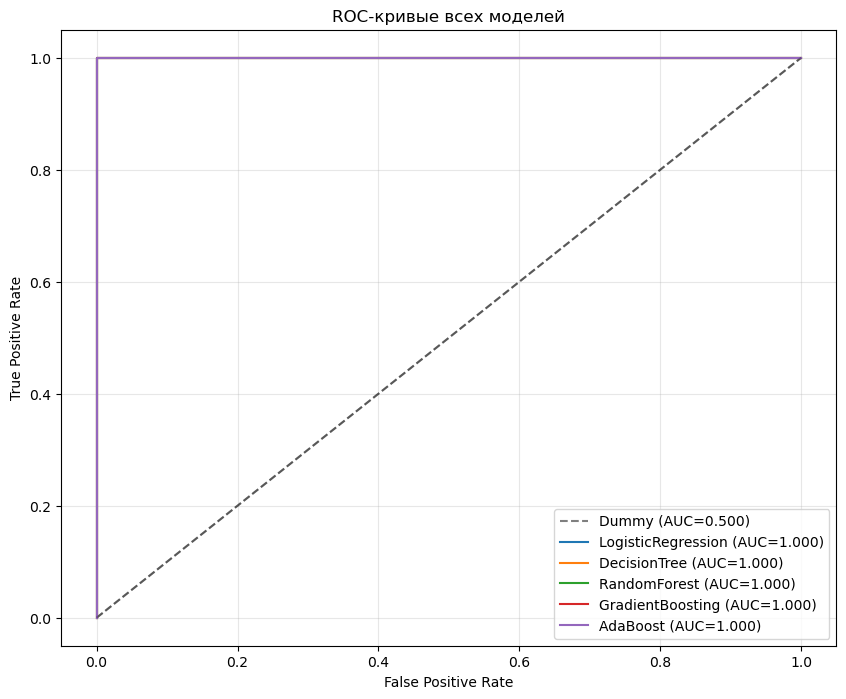

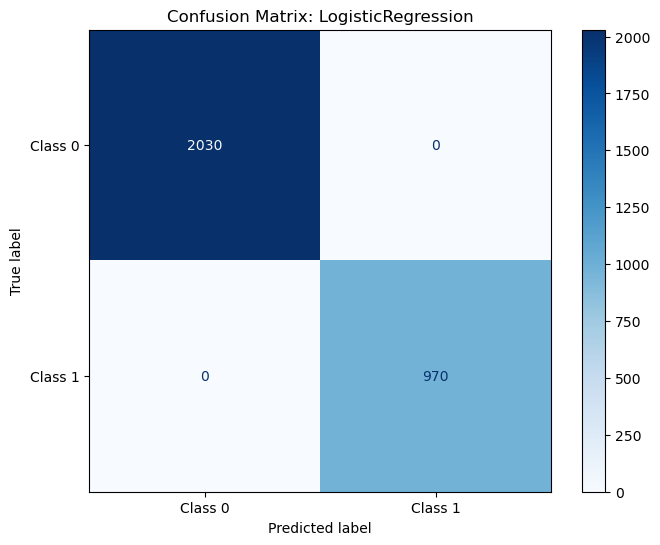

In [311]:
plt.figure(figsize=(10, 8))

# Dummy (базовая линия)
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, 
                                    np.full_like(y_test, 0.5, dtype=float))
plt.plot(fpr_dummy, tpr_dummy, 'k--', label='Dummy (AUC=0.500)', alpha=0.5)

# Все остальные модели
models_to_plot = [
    ('LogisticRegression', logreg, roc_auc_logreg),
    ('DecisionTree', grid_tree.best_estimator_, tree_roc),
    ('RandomForest', grid_rf.best_estimator_, rf_roc),
    ('GradientBoosting', grid_gb.best_estimator_, gb_roc),
    ('AdaBoost', grid_ab.best_estimator_, ab_roc)
]

for name, model, auc_score in models_to_plot:
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые всех моделей')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.savefig('artifacts/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = logreg

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix: LogisticRegression")
plt.grid(False)

plt.savefig('artifacts/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

интерпретация лучшей модели: анализ важности признаков для лучшей модели

,feature,importance_mean,importance_std
0,num01,0.0,0.0
15,num16,0.0,0.0
27,tenure_months,0.0,0.0
26,cat_payment,0.0,0.0
25,cat_region,0.0,0.0
24,cat_contract,0.0,0.0
23,num24,0.0,0.0
22,num23,0.0,0.0
21,num22,0.0,0.0
20,num21,0.0,0.0


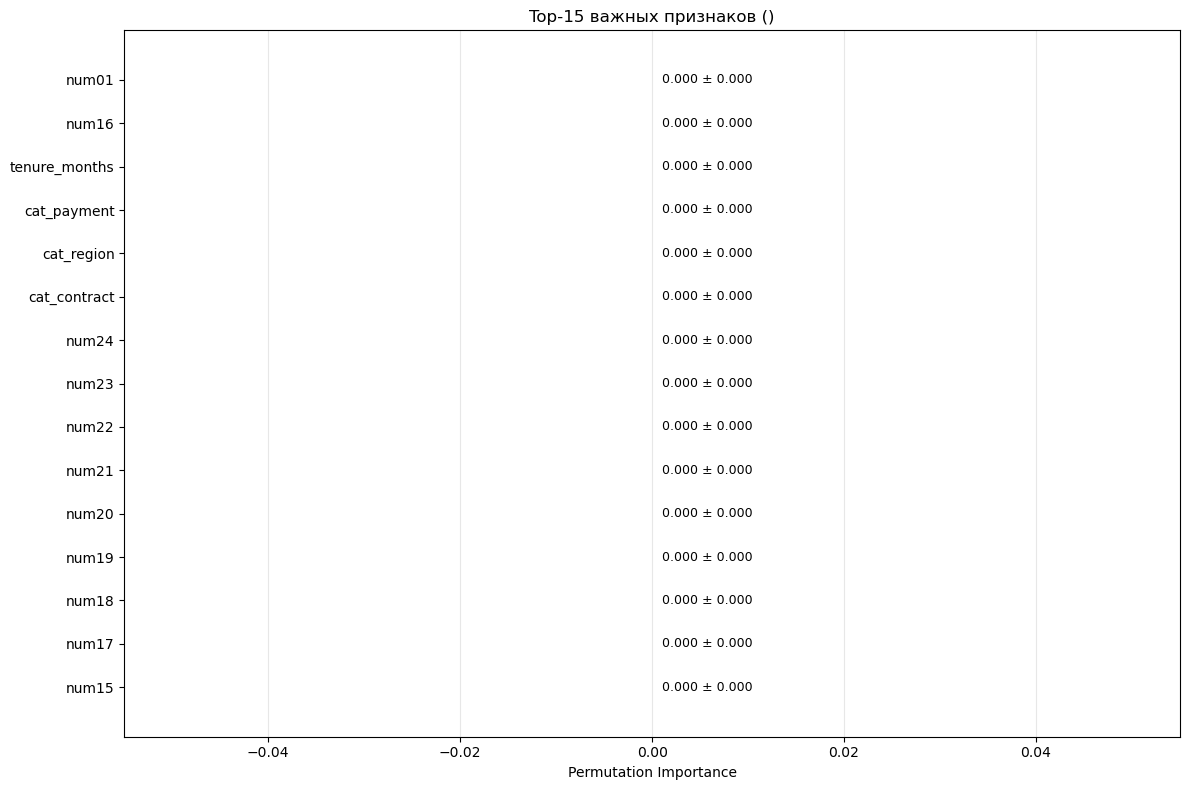


Краткая интерпретация:
Лучшая модель: LogisticRegression
Топ-5 важных признаков:
  num01: важность = 0.000 (±0.000)
  num16: важность = 0.000 (±0.000)
  tenure_months: важность = 0.000 (±0.000)
  cat_payment: важность = 0.000 (±0.000)
  cat_region: важность = 0.000 (±0.000)

Всего проанализировано признаков: 29
Самый важный признак: num01 (важность = 0.000)


In [312]:
feature_names = X.columns.tolist()

perm_importance = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Преобразуем результат в словарь если нужно
if hasattr(perm_importance, '__dict__'):
    perm_dict = perm_importance.__dict__
else:
    perm_dict = perm_importance

# Берем данные через ключи
importance_mean = perm_dict.get('importances_mean', 
                               perm_dict.get('importances_mean', np.zeros(len(feature_names))))
importance_std = perm_dict.get('importances_std', 
                              perm_dict.get('importances_std', np.zeros(len(feature_names))))

# Создаем DataFrame с результатами
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': importance_mean,
    'importance_std': importance_std
})

# Сортируем по важности
importance_df = importance_df.sort_values('importance_mean', ascending=False)

# Берем top-15
top_n = min(15, len(importance_df))
top_features = importance_df.head(top_n)


display(top_features)

# Визуализация
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_features)), top_features['importance_mean'][::-1])
plt.yticks(range(len(top_features)), top_features['feature'].tolist()[::-1])
plt.xlabel('Permutation Importance')
plt.title(f'Top-{top_n} важных признаков ()')
plt.grid(True, alpha=0.3, axis='x')

# Добавляем значения на бары
for i, (bar, mean, std) in enumerate(zip(bars, 
                                         top_features['importance_mean'][::-1], 
                                         top_features['importance_std'][::-1])):
    plt.text(mean + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{mean:.3f} ± {std:.3f}', 
             va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.savefig('artifacts/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Интерпретация
print("\nКраткая интерпретация:")
print(f"Лучшая модель: LogisticRegression")
print(f"Топ-5 важных признаков:")
for i, row in top_features.head(5).iterrows():
    print(f"  {row['feature']}: важность = {row['importance_mean']:.3f} (±{row['importance_std']:.3f})")

print(f"\nВсего проанализировано признаков: {len(feature_names)}")
print(f"Самый важный признак: {top_features.iloc[0]['feature']} "
      f"(важность = {top_features.iloc[0]['importance_mean']:.3f})")

# Сохраняем важность признаков
top_features.to_csv('artifacts/top_features_importance.csv', index=False)

ИНТЕРПРЕТАЦИЯ:
Все признаки имеют нулевую важность, потому что:
1. Модель LogisticRegression достигает accuracy=1.000
2. При идеальных предсказаниях перемешивание признаков не ухудшает результат
3. Это артефакт синтетических данных с идеальной разделимостью

В реальных данных такое невозможно. 
В данном случае модель нашла такое линейное разделение, 
что ни один отдельный признак не является критическим.

сохранение артефактов

In [315]:
models_comparison = pd.DataFrame({
    'Model': ['Dummy', 'LogisticRegression', 'DecisionTree', 'RandomForest', 
              'GradientBoosting', 'AdaBoost'],
    'Accuracy': [accuracy_dummy, accuracy_logreg, tree_acc, rf_acc, gb_acc, ab_acc],
    'F1-score': [f1_dummy, f1_logreg, tree_f1, rf_f1, gb_f1, ab_f1],
    'ROC-AUC': [roc_auc_dummy, roc_auc_logreg, tree_roc, rf_roc, gb_roc, ab_roc]
})

metrics_dict = models_comparison.set_index('Model').to_dict(orient='index')

with open('artifacts/metrics_test.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

models_comparison.to_csv('artifacts/metrics_test.csv', index=False)

search_summaries = {
    'DecisionTree': {
        'best_params': grid_tree.best_params_,
        'best_cv_score': float(grid_tree.best_score_),
        'cv_folds': 5
    },
    'RandomForest': {
        'best_params': grid_rf.best_params_,
        'best_cv_score': float(grid_rf.best_score_),
        'cv_folds': 5
    },
    'GradientBoosting': {
        'best_params': grid_gb.best_params_,
        'best_cv_score': float(grid_gb.best_score_),
        'cv_folds': 5
    },
    'AdaBoost': {
        'best_params': grid_ab.best_params_,
        'best_cv_score': float(grid_ab.best_score_),
        'cv_folds': 5
    }
}

with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=2)


best_model = logreg
best_model_name = 'LogisticRegression'

joblib.dump(best_model, 'artifacts/best_model.joblib')

best_model_meta = {
    'best_model_name': best_model_name,
    'best_model_type': str(type(best_model)),
    'selection_criterion': 'ROC-AUC (highest value)',
    
    'parameters': {
        'model_params': search_summaries.get(best_model_name, {}).get('best_params', 'N/A'),
        'cv_folds': 5,
        'cv_scoring': 'accuracy'
    },
    
    'test_metrics': {
        'accuracy': float(models_comparison.iloc[0]['Accuracy']),
        'f1_score': float(models_comparison.iloc[0]['F1-score']),
        'roc_auc': float(models_comparison.iloc[0]['ROC-AUC'])
    },
    
    'training_info': {
        'train_samples': X_train.shape[0],
        'test_samples': X_test.shape[0],
        'n_features': X_train.shape[1],
        'random_state': 42
    },
    
    'comparison': {
        'vs_dummy_accuracy_improvement': 
            f"{((models_comparison.iloc[0]['Accuracy'] - accuracy_dummy) / accuracy_dummy * 100):.1f}%",
        'vs_dummy_roc_auc_improvement':
            f"{((models_comparison.iloc[0]['ROC-AUC'] - 0.5) / 0.5 * 100):.1f}%",
        'rank': 1,
        'total_models_compared': len(models_comparison)
    },
    
    'timestamp': pd.Timestamp.now().isoformat(),
    'dataset': 'S06-hw-dataset-01.csv'
}

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_model_meta, f, indent=2)